In [1]:
# CELL 1 — INSTALL
!pip install transformers accelerate Pillow -q

In [2]:
# CELL 2 — IMPORTS
import os
import re
import pandas as pd
from PIL import Image
import torch
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from tqdm import tqdm
import shutil

In [3]:
# CELL 3 — PATHS
META_PATH   = "/kaggle/input/datasets/ankithkini/preprocessed-deepfashion-gt/all_metadata.csv"
CROPPED_DIR = "/kaggle/input/datasets/ankithkini/preprocessed-deepfashion-gt/cropped_images"
CAPTION_CSV = "/kaggle/working/captions.csv"
OUTPUT_DIR  = "/kaggle/working/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Paths ready.")
print("Meta file exists  :", os.path.exists(META_PATH))
print("Cropped dir exists:", os.path.exists(CROPPED_DIR))

Paths ready.
Meta file exists  : True
Cropped dir exists: True


In [4]:
# CELL 4 — LOAD METADATA
cropped_df = pd.read_csv(META_PATH)

cropped_df["cropped_image_path"] = cropped_df["cropped_image_path"].apply(
    lambda p: os.path.join(CROPPED_DIR, os.path.basename(p))
)

print(f"Total images      : {len(cropped_df)}")
print(f"Split counts:")
print(cropped_df["split"].value_counts())
print()
print("Columns:", cropped_df.columns.tolist())
print()

missing = cropped_df["cropped_image_path"].apply(lambda p: not os.path.exists(p)).sum()
print(f"Missing files on disk: {missing}")
print(cropped_df[["cropped_image_path", "item_id", "split", "gt_x1", "gt_y1", "gt_x2", "gt_y2"]].head())

Total images      : 52712
Split counts:
split
train      25882
query      14218
gallery    12612
Name: count, dtype: int64

Columns: ['image_path', 'relative_path', 'item_id', 'split', 'cropped_image_path', 'fallback_used', 'gt_x1', 'gt_y1', 'gt_x2', 'gt_y2']

Missing files on disk: 0
                                  cropped_image_path      item_id  split  \
0  /kaggle/input/datasets/ankithkini/preprocessed...  id_00000002  train   
1  /kaggle/input/datasets/ankithkini/preprocessed...  id_00000002  train   
2  /kaggle/input/datasets/ankithkini/preprocessed...  id_00000002  train   
3  /kaggle/input/datasets/ankithkini/preprocessed...  id_00000002  train   
4  /kaggle/input/datasets/ankithkini/preprocessed...  id_00000003  train   

   gt_x1  gt_y1  gt_x2  gt_y2  
0     65     45    233    252  
1    112     41    168    247  
2     89     34    169    167  
3     73     40    194    251  
4     51    122    160    210  


In [5]:
# CELL 5 — LOAD BLIP-2
MODEL_ID = "Salesforce/blip2-opt-2.7b"

processor = Blip2Processor.from_pretrained(MODEL_ID)
model = Blip2ForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()
print("BLIP-2 loaded.")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['query_tokens']
  warnings.warn(


BLIP-2 loaded.


In [6]:
# CELL 6 — KEEP-ALIVE THREAD
import time
import threading

def keep_alive():
    while True:
        time.sleep(30)
        _ = 1 + 1

thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()
print("Keep-alive started.")

Keep-alive started.


In [9]:
# CELL 7 — CAPTION FUNCTION
PROMPT        = "Question: What clothing item is shown? Describe its color, style, and garment type in one sentence. Answer: This is"
PROMPT_ANCHOR = "Question: Focus only on the clothing, not the person. What single garment is most prominent? Describe its color and style. Answer:"

def caption_batch_with_prompt(image_paths, prompt):
    images = []
    for p in image_paths:
        try:
            images.append(Image.open(p).convert("RGB"))
        except Exception:
            images.append(Image.new("RGB", (224, 224)))

    inputs = processor(
        images=images,
        text=[prompt] * len(images),
        return_tensors="pt",
        padding=True
    ).to("cuda", torch.float16)

    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=60,
            num_beams=1,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3
        )

    captions = processor.tokenizer.batch_decode(
        generated_ids[:, prompt_len:],
        skip_special_tokens=True
    )
    return [c.strip() for c in captions]

def caption_batch(image_paths):
    return caption_batch_with_prompt(image_paths, PROMPT)

In [10]:
# CELL 8 — BATCHED CAPTIONING LOOP (with resume + checkpointing)
BATCH_SIZE       = 32
CHECKPOINT_EVERY = 5000

if os.path.exists(CAPTION_CSV):
    done_df    = pd.read_csv(CAPTION_CSV)
    done_paths = set(done_df["cropped_image_path"].tolist())
    print(f"Resuming — {len(done_paths)} already captioned.")
else:
    done_df    = pd.DataFrame(columns=[
        "cropped_image_path", "item_id", "split", "caption",
        "gt_x1", "gt_y1", "gt_x2", "gt_y2"
    ])
    done_paths = set()

to_do = cropped_df[~cropped_df["cropped_image_path"].isin(done_paths)].reset_index(drop=True)
print(f"Remaining: {len(to_do)}")

results = []

for start in tqdm(range(0, len(to_do), BATCH_SIZE), desc="Captioning"):
    batch    = to_do.iloc[start : start + BATCH_SIZE]
    captions = caption_batch(batch["cropped_image_path"].tolist())

    for (_, row), caption in zip(batch.iterrows(), captions):
        results.append({
            "cropped_image_path" : row["cropped_image_path"],
            "item_id"            : row["item_id"],
            "split"              : row["split"],
            "caption"            : caption,
            "gt_x1"              : row.get("gt_x1"),
            "gt_y1"              : row.get("gt_y1"),
            "gt_x2"              : row.get("gt_x2"),
            "gt_y2"              : row.get("gt_y2"),
        })

    if len(results) >= CHECKPOINT_EVERY:
        batch_df = pd.DataFrame(results)
        combined = pd.concat([done_df, batch_df], ignore_index=True)
        combined.to_csv(CAPTION_CSV, index=False)
        done_df  = combined
        results  = []
        print(f"Checkpoint saved — {len(done_df)} done")

if results:
    combined = pd.concat([done_df, pd.DataFrame(results)], ignore_index=True)
    combined.to_csv(CAPTION_CSV, index=False)
    print(f"Final save — {len(combined)} total")

print(f"Done. Total: {len(pd.read_csv(CAPTION_CSV))}")

Remaining: 52712



Captioning:   0%|          | 0/1648 [00:00<?, ?it/s]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:   0%|          | 1/1648 [00:02<1:02:04,  2.26s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:   0%|          | 2/1648 [00:04<1:00:0

Checkpoint saved — 5024 done


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  10%|▉         | 158/1648 [06:17<1:02:24,  2.51s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  10%|▉         | 159/1648 [06:19<1:00:50,  2.45s/it]The `language_model` is not in the `

Checkpoint saved — 10048 done


...

Checkpoint saved — 45216 done


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  86%|████████▌ | 1414/1648 [56:29<09:38,  2.47s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  86%|████████▌ | 1415/1648 [56:31<09:23,  2.42s/it]The `language_model` is not in the `hf

Checkpoint saved — 50240 done


The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  95%|█████████▌| 1571/1648 [1:02:49<03:12,  2.50s/it]The `language_model` is not in the `hf_device_map` dictionary and you are running your script in a multi-GPU environment. this may lead to unexpected behavior when using `accelerate`. Please pass a `device_map` that contains `language_model` to remove this warning. Please refer to https://github.com/huggingface/blog/blob/main/accelerate-large-models.md for more details on creating a `device_map` for large models.

Captioning:  95%|█████████▌| 1572/1648 [1:02:52<03:08,  2.48s/it]The `language_model` is not in the

Final save — 52712 total
Done. Total: 52712


In [11]:
# CELL 8b — FLAG PERSON-RELATED CAPTIONS
PERSON_KEYWORDS = ["a person", "a woman", "a man", "a model", "person", "woman", "man", "model"]

captions_df = pd.read_csv(CAPTION_CSV)

def is_person_related(text):
    if not isinstance(text, str) or text.strip() in ["", "a"]:
        return True
    t = text.strip().lower()
    return any(t.startswith(kw) for kw in PERSON_KEYWORDS)

person_mask = captions_df["caption"].apply(is_person_related)
print(f"Person-related / empty captions to re-caption: {person_mask.sum()}")

Person-related / empty captions to re-caption: 3748


In [12]:
# CELL 8c — RE-CAPTION PERSON-RELATED WITH ANCHOR PROMPT
recaption_df = captions_df[person_mask].reset_index(drop=True)
new_captions = []

for start in tqdm(range(0, len(recaption_df), BATCH_SIZE), desc="Re-captioning"):
    batch    = recaption_df.iloc[start : start + BATCH_SIZE]
    captions = caption_batch_with_prompt(batch["cropped_image_path"].tolist(), PROMPT_ANCHOR)
    new_captions.extend(captions)

captions_df.loc[person_mask, "caption"] = new_captions
captions_df.to_csv(CAPTION_CSV, index=False)
print(f"Re-captioned {len(new_captions)} images.")
print("Sample re-captions:")
for c in new_captions[:5]:
    print(" -", c)

Re-captioning: 100%|██████████| 118/118 [04:27<00:00,  2.27s/it]


Re-captioned 3748 images.
Sample re-captions:
 - The off shoulder top
 - The dress
 - The dress
 - a white dress with blue trim
 - The red floral dress


In [13]:
# CELL 9 — COPY TO OUTPUT
shutil.copy(CAPTION_CSV, os.path.join(OUTPUT_DIR, "captions.csv"))
print("Saved to output/captions.csv")

Saved to output/captions.csv


In [14]:
# CELL 10 — BASIC VALIDATION
captions_df = pd.read_csv(CAPTION_CSV)

print("Shape           :", captions_df.shape)
print("Missing captions:", captions_df["caption"].isna().sum())
print("Split counts:")
print(captions_df["split"].value_counts())
print()
print(captions_df[["item_id", "split", "caption"]].head(10).to_string())

Shape           : (52712, 8)
Missing captions: 1
Split counts:
split
train      25882
query      14218
gallery    12612
Name: count, dtype: int64

       item_id  split                                                caption
0  id_00000002  train                                   a floral print dress
1  id_00000002  train                  a floral print off the shoulder dress
2  id_00000002  train                                   a floral print dress
3  id_00000002  train                                   a black floral dress
4  id_00000003  train                    a black top with gray pleated skirt
5  id_00000003  train                          a black dress with white trim
6  id_00000003  train                                                a skirt
7  id_00000003  train                 a black blouse with gray pleated skirt
8  id_00000003  train                    a black top with grey pleated skirt
9  id_00000004  train  a black off the shoulder top with embroidered sleeves


In [15]:
# CELL 11 — FILL EMPTY CAPTIONS WITH FALLBACK
captions_df = pd.read_csv(CAPTION_CSV)

empty_mask = captions_df["caption"].isna() | (captions_df["caption"].str.strip() == "")
print(f"Empty captions before: {empty_mask.sum()}")

captions_df.loc[empty_mask, "caption"] = "a clothing item"
captions_df.to_csv(CAPTION_CSV, index=False)
print(f"Empty captions after : {captions_df['caption'].isna().sum()}")

Empty captions before: 1
Empty captions after : 0


In [16]:
# CELL 12 — CLEAN CAPTIONS (deduplicate repeated phrases)
captions_df = pd.read_csv(CAPTION_CSV)

def clean_caption(text):
    if not isinstance(text, str) or text.strip() == "":
        return "a clothing item"
    parts   = [p.strip() for p in text.split(",")]
    seen    = []
    for p in parts:
        if p not in seen:
            seen.append(p)
    cleaned = ", ".join(seen)
    if len(cleaned) > 120:
        cleaned = ", ".join(seen[:4])
    return cleaned if cleaned else "a clothing item"

captions_df["caption"] = captions_df["caption"].apply(clean_caption)
captions_df.to_csv(CAPTION_CSV, index=False)

print(f"Total captions: {len(captions_df)}")
print("Sample captions:")
for c in captions_df["caption"].sample(5, random_state=42).tolist():
    print(" -", c)

Total captions: 52712
Sample captions:
 - a black denim shorts
 - a t - shirt
 - a black shorts with white print
 - The t shirt
 - a white sweater


In [17]:
# CELL 13 — FINAL QUALITY CHECK
captions_df = pd.read_csv(CAPTION_CSV)

null_mask     = captions_df["caption"].isna()
empty_mask    = captions_df["caption"].str.strip() == ""
fallback_mask = captions_df["caption"].str.strip() == "a clothing item"

print(f"Total rows           : {len(captions_df)}")
print(f"NaN captions         : {null_mask.sum()}")
print(f"Empty string         : {empty_mask.sum()}")
print(f"Fallback placeholder : {fallback_mask.sum()}")
print(f"Total problematic    : {(null_mask | empty_mask).sum()}")

Total rows           : 52712
NaN captions         : 0
Empty string         : 0
Fallback placeholder : 1
Total problematic    : 0


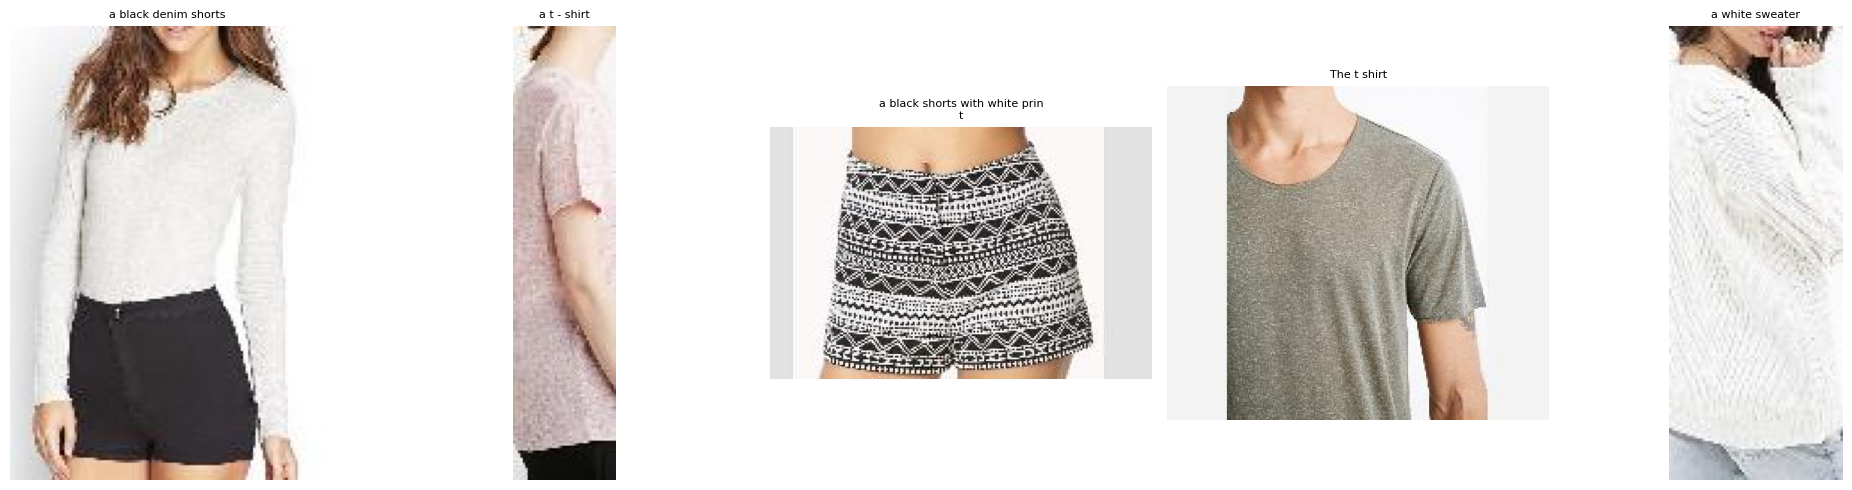

Sample plot saved.


In [18]:
# CELL 14 — VISUALISE SAMPLE CAPTIONS
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

captions_df = pd.read_csv(CAPTION_CSV)
samples = captions_df.sample(5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (_, row) in zip(axes, samples.iterrows()):
    try:
        img = mpimg.imread(row["cropped_image_path"])
        ax.imshow(img)
    except Exception:
        ax.set_facecolor("lightgray")
    ax.axis("off")
    caption = row["caption"]
    wrapped = "\n".join([caption[i:i+30] for i in range(0, len(caption), 30)])
    ax.set_title(wrapped, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "caption_samples.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Sample plot saved.")